Detected 396 polysomes across 129 tomograms.


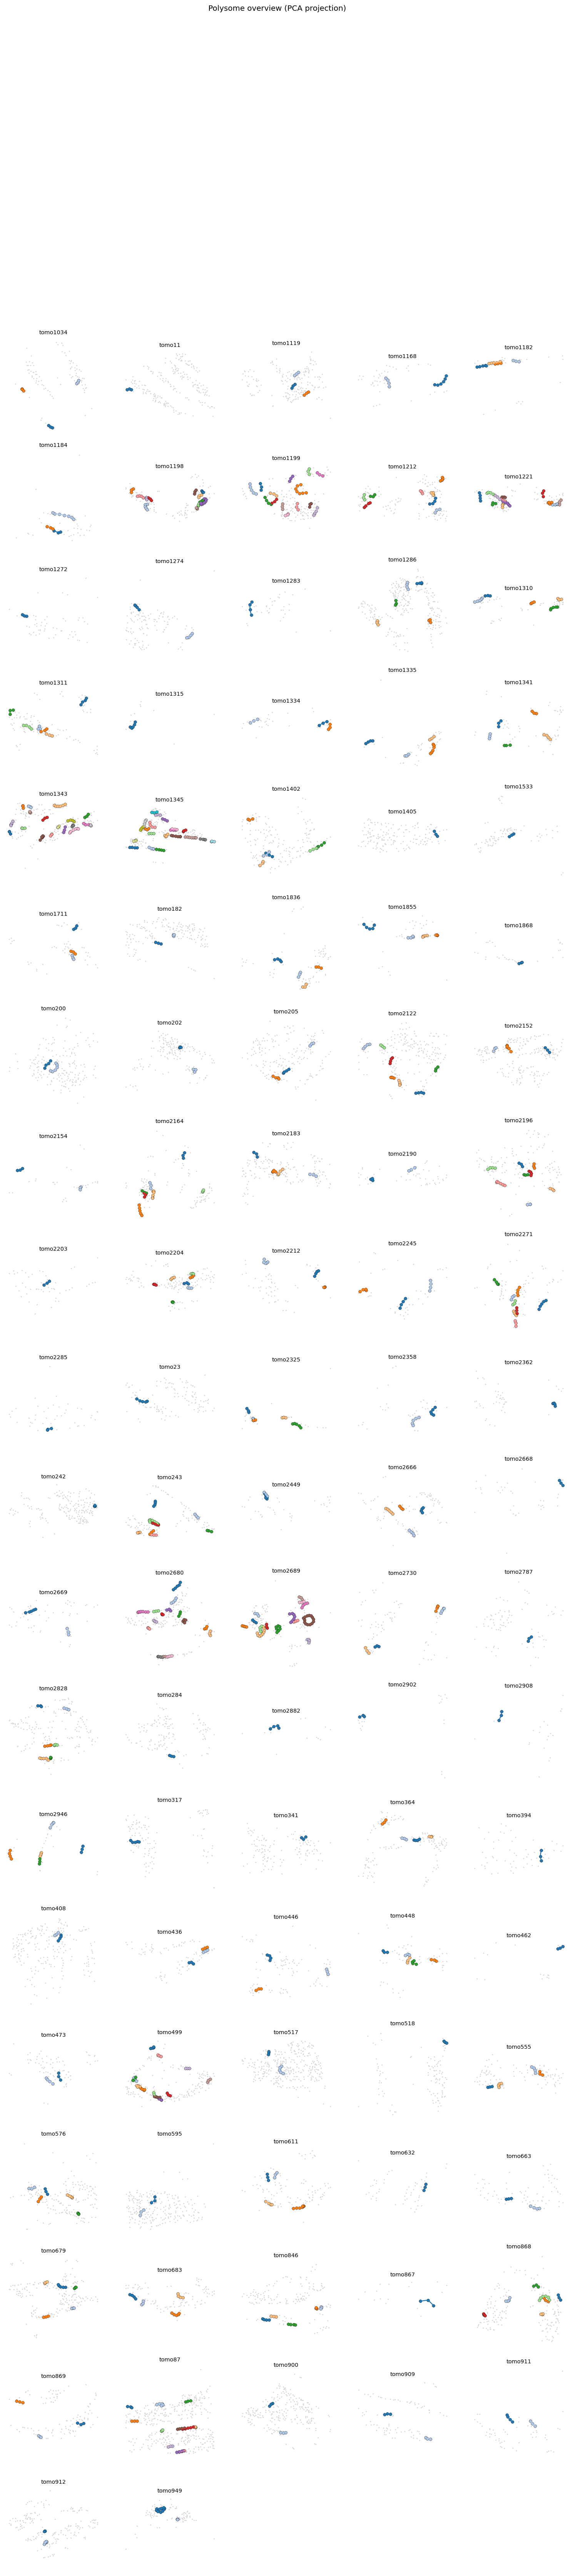

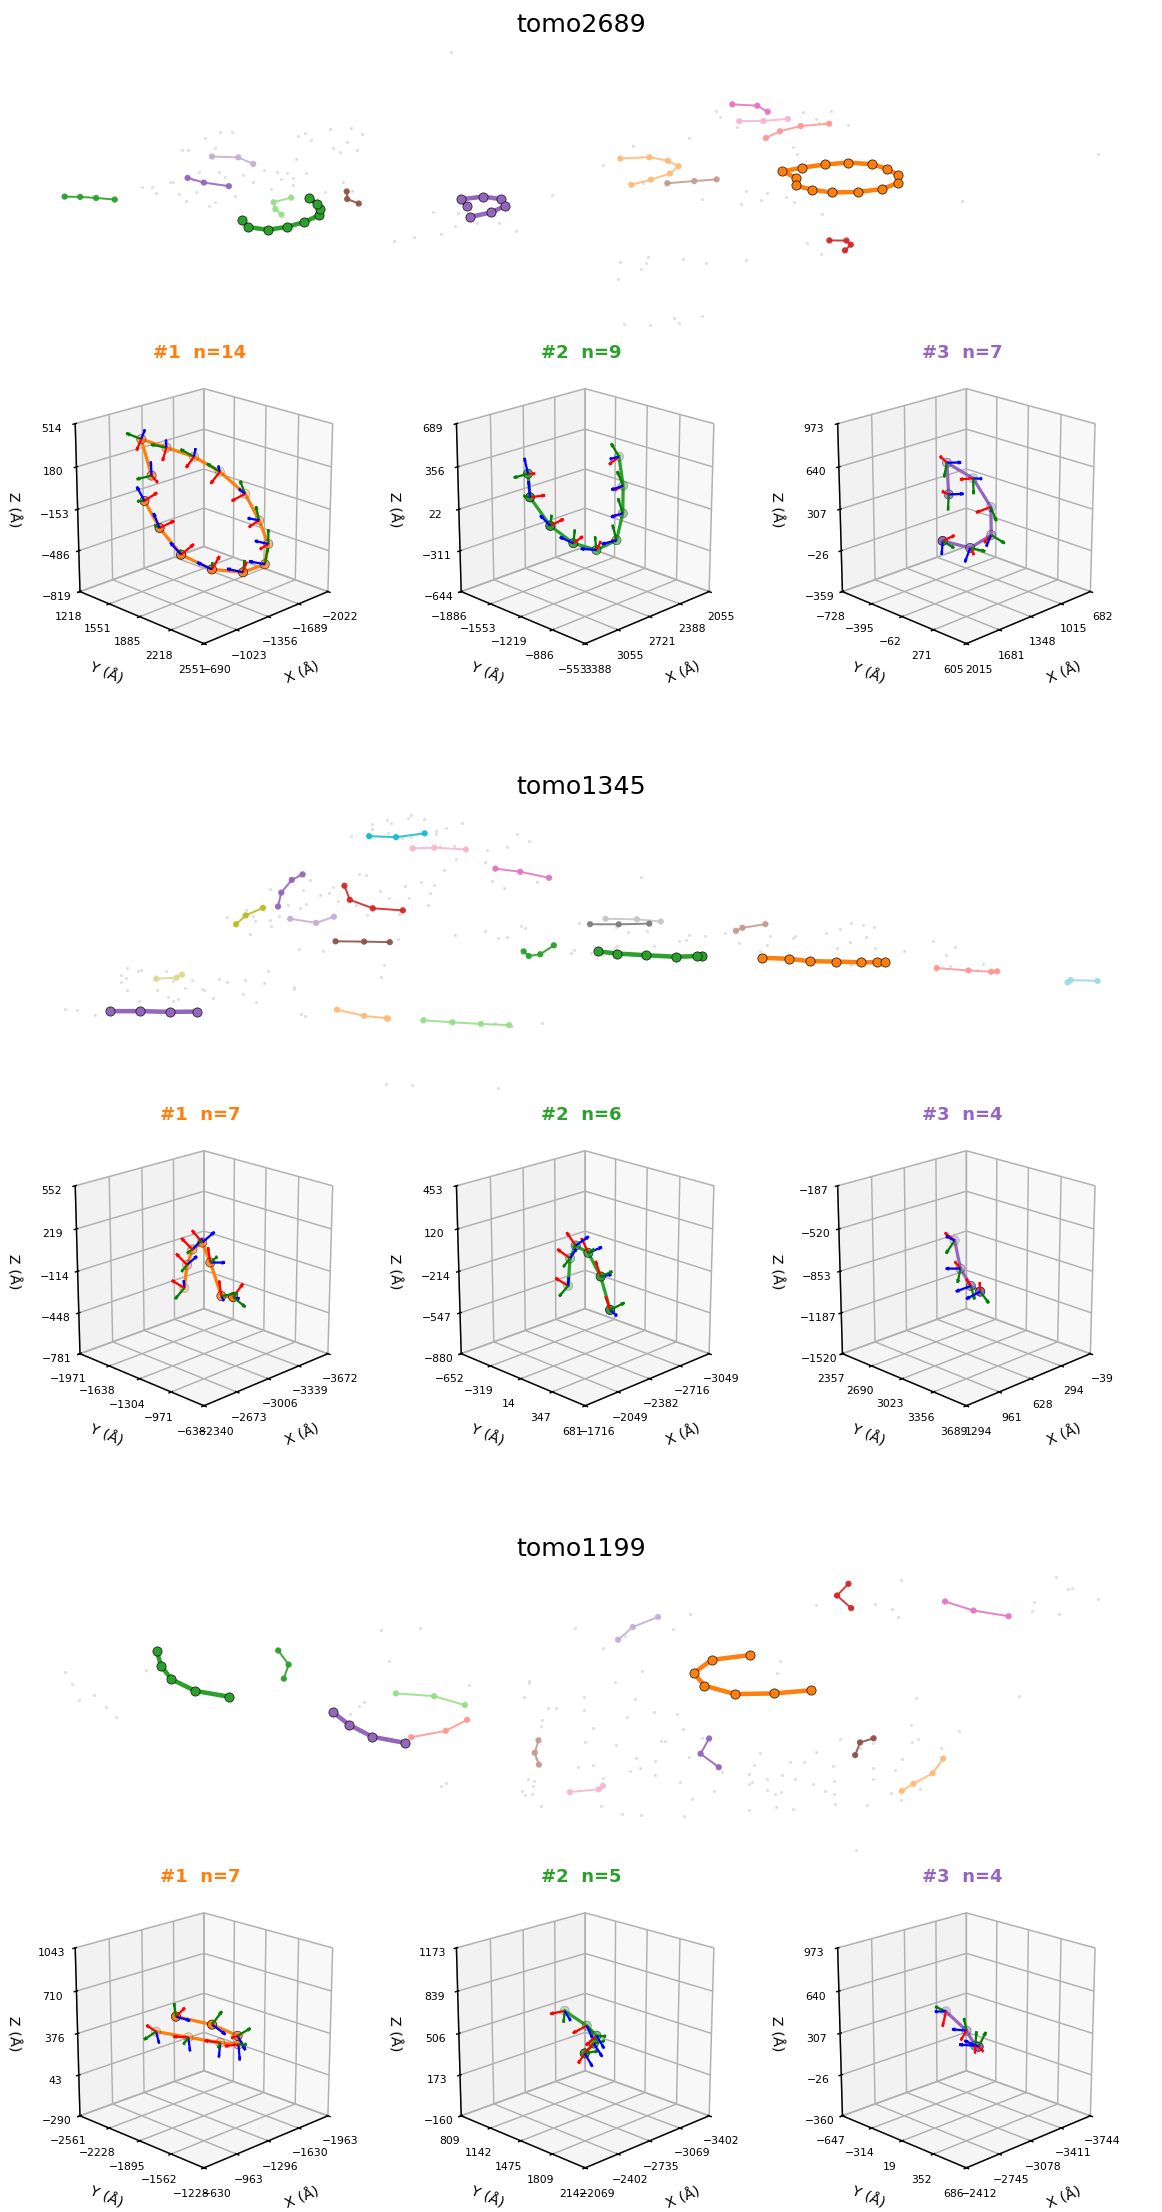

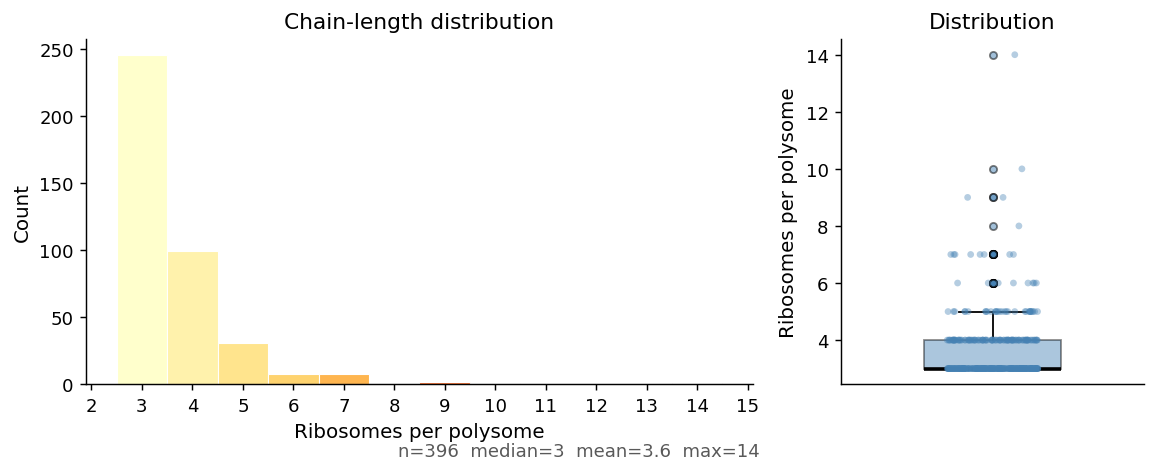

In [79]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import starfile
from scipy.spatial import cKDTree
from scipy.spatial.transform import Rotation

# ── parameters ────────────────────────────────────────────────────────────────
STAR_PATH = "ribo_ptcls.star"

COORD_COLS = [
    "rlnCenteredCoordinateXAngst",
    "rlnCenteredCoordinateYAngst",
    "rlnCenteredCoordinateZAngst",
]
ANGLE_COLS = ["rlnAngleRot", "rlnAngleTilt", "rlnAnglePsi"]
TOMO_COL = "rlnTomoName"

MIN_EDGE_A = 200
MAX_EDGE_A = 320
MAX_SO3_DEG = 60
MIN_POLYSOME_SIZE = 3
MAX_DEGREE = 2

DETAIL_TOMOS = ["tomo2689", "tomo1345", "tomo1199"]
TOP_N = 3
ARROW_LEN = 120
HIGHLIGHT_COLORS = ["tab:orange", "tab:green", "tab:purple"]

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ── helpers ───────────────────────────────────────────────────────────────────
def read_particles(path):
    obj = starfile.read(path)

    if isinstance(obj, dict):
        if "particles" in obj:
            df = obj["particles"].copy()
        else:
            hits = [k for k in obj if "particle" in k.lower()]
            if len(hits) == 1:
                df = obj[hits[0]].copy()
            else:
                raise ValueError("Could not find particles block in STAR file.")
    else:
        df = obj.copy()

    for c in COORD_COLS + ANGLE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.dropna(subset=COORD_COLS + ANGLE_COLS + [TOMO_COL]).reset_index(drop=True)


def so3_angle(r1, r2):
    return float(np.degrees((r1.inv() * r2).magnitude()))


def candidate_edges(xyz, rots):
    edges = []

    for i, j in cKDTree(xyz).query_pairs(MAX_EDGE_A):
        d = float(np.linalg.norm(xyz[i] - xyz[j]))
        if d < MIN_EDGE_A:
            continue

        a = so3_angle(rots[i], rots[j])
        if a <= MAX_SO3_DEG:
            edges.append((i, j, d, a))

    return edges


def pick_edges(n, edges):
    parent = np.arange(n)
    size = np.ones(n, dtype=int)
    degree = np.zeros(n, dtype=int)
    picked = []

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        a, b = find(a), find(b)
        if a == b:
            return
        if size[a] < size[b]:
            a, b = b, a
        parent[b] = a
        size[a] += size[b]

    for i, j, d, a in sorted(edges, key=lambda z: (z[2], z[3])):
        if degree[i] >= MAX_DEGREE or degree[j] >= MAX_DEGREE:
            continue

        ri, rj = find(i), find(j)

        if ri != rj:
            picked.append((i, j))
            degree[i] += 1
            degree[j] += 1
            union(i, j)

        elif degree[i] == 1 and degree[j] == 1 and size[ri] >= MIN_POLYSOME_SIZE:
            picked.append((i, j))
            degree[i] += 1
            degree[j] += 1

    return picked


def get_components(n, edges):
    adj = [[] for _ in range(n)]

    for i, j in edges:
        adj[i].append(j)
        adj[j].append(i)

    seen = np.zeros(n, dtype=bool)
    comps = []

    for s in range(n):
        if seen[s] or not adj[s]:
            continue

        stack = [s]
        seen[s] = True
        comp = []

        while stack:
            u = stack.pop()
            comp.append(u)

            for v in adj[u]:
                if not seen[v]:
                    seen[v] = True
                    stack.append(v)

        comps.append(comp)

    return comps, adj


def is_valid(comp, adj):
    if len(comp) < MIN_POLYSOME_SIZE:
        return False

    deg = [len(adj[u]) for u in comp]
    if max(deg) > MAX_DEGREE:
        return False

    open_chain = deg.count(1) == 2 and deg.count(2) == len(comp) - 2
    closed_ring = deg.count(2) == len(comp)

    return open_chain or closed_ring


def order_component(nodes, edges):
    nodes = list(nodes)
    node_set = set(nodes)

    adj = {u: [] for u in nodes}
    for i, j in edges:
        if i in node_set and j in node_set:
            adj[i].append(j)
            adj[j].append(i)

    ends = [u for u in nodes if len(adj[u]) == 1]

    if len(ends) == 2:
        start = ends[0]
        order = [start]
        prev, cur = None, start

        while True:
            nxts = [v for v in adj[cur] if v != prev]
            if not nxts:
                break

            nxt = nxts[0]
            if nxt in order:
                break

            order.append(nxt)
            prev, cur = cur, nxt

        return order

    start = min(nodes)
    order = [start]
    prev, cur = None, start

    while True:
        nxts = [v for v in adj[cur] if v != prev and v not in order]

        if not nxts:
            break

        nxt = nxts[0]
        order.append(nxt)
        prev, cur = cur, nxt

        if len(order) == len(nodes):
            break

    return order


def pca_proj(xyz):
    c = xyz.mean(axis=0)
    X = xyz - c
    B = np.linalg.svd(X, full_matrices=False)[2][:2].T if len(xyz) >= 3 else np.eye(3)[:, :2]
    return lambda x: (x - c) @ B


def detect_polysomes(g):
    g = g.reset_index(drop=True)

    xyz = g[COORD_COLS].to_numpy(float)
    rots = Rotation.from_euler("ZYZ", g[ANGLE_COLS].to_numpy(float), degrees=True)

    edges = pick_edges(len(g), candidate_edges(xyz, rots))
    comps, adj = get_components(len(g), edges)

    polysomes = []
    for comp in comps:
        if is_valid(comp, adj):
            s = set(comp)
            comp_edges = [(i, j) for i, j in edges if i in s and j in s]
            polysomes.append((comp, comp_edges))

    return {"tomo": str(g[TOMO_COL].iloc[0]), "xyz": xyz, "polysomes": polysomes}


def norm_tomo_name(x):
    x = str(x)
    return x if x.startswith("tomo") else f"tomo{x}"


def set_zoom_and_ticks(ax, pts, half_range, n_ticks=5):
    c = pts.mean(axis=0)

    xlim = (c[0] - half_range, c[0] + half_range)
    ylim = (c[1] - half_range, c[1] + half_range)
    zlim = (c[2] - half_range, c[2] + half_range)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)
    ax.set_box_aspect([1, 1, 1])

    ax.set_xticks(np.round(np.linspace(*xlim, n_ticks), 0))
    ax.set_yticks(np.round(np.linspace(*ylim, n_ticks), 0))
    ax.set_zticks(np.round(np.linspace(*zlim, n_ticks), 0))

    ax.set_xlabel("X (Å)", fontsize=8, labelpad=1)
    ax.set_ylabel("Y (Å)", fontsize=8, labelpad=1)
    ax.set_zlabel("Z (Å)", fontsize=8, labelpad=1)

    ax.tick_params(axis="both", which="major", labelsize=6, pad=0)
    ax.zaxis.set_tick_params(labelsize=6, pad=0)


# ── run detection ─────────────────────────────────────────────────────────────
particles = read_particles(STAR_PATH)
results = [detect_polysomes(g) for _, g in particles.groupby(TOMO_COL)]

print(f"Detected {sum(len(r['polysomes']) for r in results)} polysomes across {len(results)} tomograms.")


# ── overview plot ─────────────────────────────────────────────────────────────
active = [r for r in results if r["polysomes"]]

if active:
    ncols = min(5, len(active))
    nrows = math.ceil(len(active) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(2.9 * ncols, 2.9 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()
    cmap = plt.colormaps["tab20"]

    for ax, r in zip(axes, active):
        P = pca_proj(r["xyz"])
        bg = P(r["xyz"])

        ax.scatter(bg[:, 0], bg[:, 1], s=3, color="0.85", lw=0)

        for k, (nodes, edges) in enumerate(r["polysomes"]):
            order = order_component(nodes, edges)
            xy = P(r["xyz"][order])
            color = cmap(k % 20)

            ax.plot(xy[:, 0], xy[:, 1], color=color, lw=1.3)
            ax.scatter(xy[:, 0], xy[:, 1], s=18, color=color, edgecolor="k", lw=0.25)

        ax.set_title(r["tomo"], fontsize=8)
        ax.set_aspect("equal")
        ax.axis("off")

    for ax in axes[len(active):]:
        ax.axis("off")

    fig.suptitle("Polysome overview (PCA projection)", y=0.995, fontsize=11)
    plt.show()


# ── detail plot for selected tomograms ────────────────────────────────────────
rows = []
all_zoom_pts = []

for tomo_name in DETAIL_TOMOS:
    tomo_name = norm_tomo_name(tomo_name)
    r = next((rr for rr in results if norm_tomo_name(rr["tomo"]) == tomo_name), None)

    if r is None or not r["polysomes"]:
        continue

    g = particles[particles[TOMO_COL].astype(str) == r["tomo"]].reset_index(drop=True)

    xyz_all = g[COORD_COLS].to_numpy(float)
    rot_all = Rotation.from_euler("ZYZ", g[ANGLE_COLS].to_numpy(float), degrees=True)
    P = pca_proj(xyz_all)

    polys = []
    for nodes, edges in r["polysomes"]:
        order = order_component(nodes, edges)
        polys.append({
            "nodes": nodes,
            "edges": edges,
            "order": order,
            "n": len(nodes),
        })

    polys = sorted(polys, key=lambda z: z["n"], reverse=True)

    top = []
    for k, poly in enumerate(polys[:TOP_N]):
        pts = xyz_all[poly["order"]]
        top.append({
            "rank": k + 1,
            "color": HIGHLIGHT_COLORS[k],
            "n": poly["n"],
            "pts": pts,
            "rots": rot_all[poly["order"]],
            "nodes": poly["nodes"],
            "edges": poly["edges"],
        })
        all_zoom_pts.append(pts)

    rows.append({
        "tomo": r["tomo"],
        "xyz_all": xyz_all,
        "polys": polys,
        "P": P,
        "top": top,
    })

if rows:
    half_range = max(np.ptp(pts, axis=0).max() for pts in all_zoom_pts) / 2 + 120

    fig = plt.figure(figsize=(9.5, 5.8 * len(rows)))
    outer = fig.add_gridspec(
        len(rows),
        1,
        left=0.04,
        right=0.96,
        top=0.98,
        bottom=0.03,
        hspace=0.22,
    )
    cmap = plt.colormaps["tab20"]

    for ri, row in enumerate(rows):
        gs = outer[ri].subgridspec(
            2,
            3,
            height_ratios=[1.0, 1.0],
            hspace=0.08,
            wspace=0.02,
        )

        ax0 = fig.add_subplot(gs[0, :])
        bg = row["P"](row["xyz_all"])

        ax0.scatter(bg[:, 0], bg[:, 1], s=3, color="0.88", lw=0, zorder=1)

        for k, poly in enumerate(row["polys"]):
            color = cmap(k % 20)
            xy = row["P"](row["xyz_all"][poly["order"]])

            ax0.plot(xy[:, 0], xy[:, 1], color=color, lw=1.1, alpha=0.9, zorder=2)
            ax0.scatter(xy[:, 0], xy[:, 1], s=12, color=color, edgecolor="none", alpha=0.95, zorder=3)

        for top in row["top"]:
            xy = row["P"](top["pts"])

            ax0.plot(xy[:, 0], xy[:, 1], color=top["color"], lw=2.5, zorder=4)
            ax0.scatter(
                xy[:, 0],
                xy[:, 1],
                s=26,
                color=top["color"],
                edgecolor="k",
                lw=0.35,
                zorder=5,
            )

        ax0.set_title(row["tomo"], fontsize=14, pad=4)
        ax0.set_aspect("auto")
        ax0.axis("off")

        for j in range(3):
            ax = fig.add_subplot(gs[1, j], projection="3d")

            if j >= len(row["top"]):
                ax.axis("off")
                continue

            top = row["top"][j]
            pts = top["pts"]
            rots = top["rots"]
            color = top["color"]

            ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color=color, lw=1.8, zorder=2)
            ax.scatter(
                pts[:, 0],
                pts[:, 1],
                pts[:, 2],
                s=26,
                color=color,
                edgecolor="k",
                lw=0.35,
                zorder=3,
            )

            for vec, axis_color in zip([[1, 0, 0], [0, 1, 0], [0, 0, 1]], ["r", "g", "b"]):
                v = rots.apply(vec)
                ax.quiver(
                    pts[:, 0],
                    pts[:, 1],
                    pts[:, 2],
                    v[:, 0],
                    v[:, 1],
                    v[:, 2],
                    length=ARROW_LEN,
                    normalize=True,
                    color=axis_color,
                    linewidth=1.25,
                    arrow_length_ratio=0.25,
                )

            set_zoom_and_ticks(ax, pts, half_range, n_ticks=5)
            ax.set_title(
                f"#{top['rank']}  n={top['n']}",
                fontsize=10,
                color=color,
                weight="bold",
                pad=3,
            )
            ax.view_init(elev=20, azim=45)

    plt.show()


# ── histogram + boxplot ───────────────────────────────────────────────────────
chain_lengths = np.array([len(nodes) for r in results for nodes, _ in r["polysomes"]])

if chain_lengths.size == 0:
    print("No polysomes detected.")
else:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(9, 3.6),
        gridspec_kw={"width_ratios": [2.2, 1]},
    )

    bins = np.arange(chain_lengths.min() - 0.5, chain_lengths.max() + 1.5)

    counts, _, patches = axes[0].hist(
        chain_lengths,
        bins=bins,
        color="steelblue",
        edgecolor="white",
        linewidth=0.6,
    )

    norm_c = plt.Normalize(chain_lengths.min(), chain_lengths.max())
    cmap_h = plt.colormaps["YlOrRd"]

    for patch, left in zip(patches, bins[:-1]):
        patch.set_facecolor(cmap_h(norm_c(left + 0.5)))

    axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))
    axes[0].set_xlabel("Ribosomes per polysome", fontsize=11)
    axes[0].set_ylabel("Count", fontsize=11)
    axes[0].set_title("Chain-length distribution", fontsize=12)

    axes[1].boxplot(
        chain_lengths,
        widths=0.45,
        patch_artist=True,
        medianprops=dict(color="k", linewidth=2),
        boxprops=dict(facecolor="steelblue", alpha=0.45),
        flierprops=dict(
            marker="o",
            markerfacecolor="steelblue",
            markersize=4,
            linestyle="none",
            alpha=0.5,
        ),
    )

    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(chain_lengths))
    axes[1].scatter(
        1 + jitter,
        chain_lengths,
        s=14,
        alpha=0.4,
        color="steelblue",
        edgecolor="none",
        zorder=3,
    )

    axes[1].set_ylabel("Ribosomes per polysome", fontsize=11)
    axes[1].set_title("Distribution", fontsize=12)
    axes[1].set_xticks([])

    stats = (
        f"n={len(chain_lengths)}  "
        f"median={np.median(chain_lengths):.0f}  "
        f"mean={chain_lengths.mean():.1f}  "
        f"max={chain_lengths.max()}"
    )
    fig.text(0.5, 0.01, stats, ha="center", fontsize=10, color="0.35")

    plt.tight_layout()
    plt.show()